# 13. MovieLens İçerik Tabanlı Film Önerisi

**Kategori:** Öneri Sistemleri  
**Gerçek veri seti:** GroupLens MovieLens latest-small  
**Veri kaynağı:** [https://grouplens.org/datasets/movielens/latest/](https://grouplens.org/datasets/movielens/latest/)  
**Amaç:** Film türlerinden kosinüs uzaklığıyla benzer filmler önermek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Film kataloğu EDA'sı

Film sayısı: 9742 | Eksik tür: 34


,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0


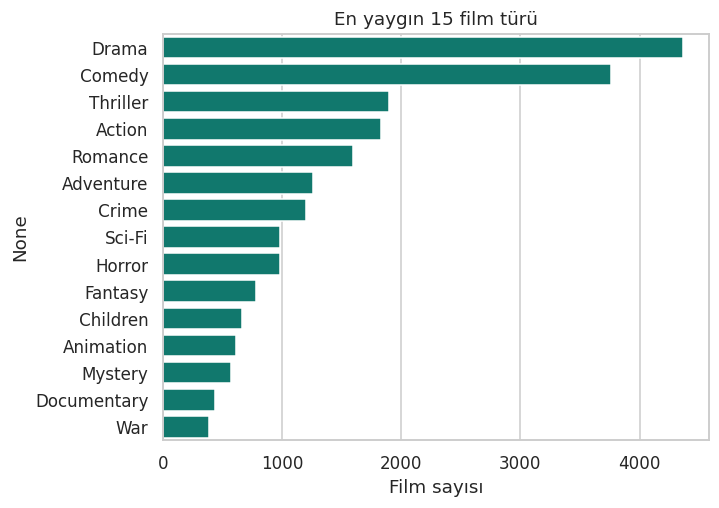

In [2]:
movies = pd.read_csv(DATA_DIR / "movielens_movies.csv")
movies["year"] = pd.to_numeric(movies.title.str.extract(r"\((\d{4})\)\s*$")[0], errors="coerce")
display(movies.head())
print("Film sayısı:", len(movies), "| Eksik tür:", (movies.genres == "(no genres listed)").sum())
genre_counts = movies.genres.str.get_dummies(sep="|").sum().sort_values(ascending=False).head(15)
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#00897B")
plt.title("En yaygın 15 film türü"); plt.xlabel("Film sayısı"); plt.show()

## 2. İçerik vektörleri ve yakın komşular

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

genre_text = movies.genres.str.replace("|", " ", regex=False).replace("(no genres listed)", "unknown")
vectorizer = TfidfVectorizer(token_pattern="[A-Za-z-]+")
matrix = vectorizer.fit_transform(genre_text)
model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=11).fit(matrix)

def recommend(title, n=5):
    idx = movies.index[movies.title.eq(title)][0]
    distances, indices = model.kneighbors(matrix[idx], n_neighbors=n + 1)
    return movies.iloc[indices[0][1:]][["movieId", "title", "genres"]].assign(
        similarity=(1 - distances[0][1:]).round(3)
    )

example_title = "Toy Story (1995)"
display(recommend(example_title))

,movieId,title,genres,similarity
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
8927,136016,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0


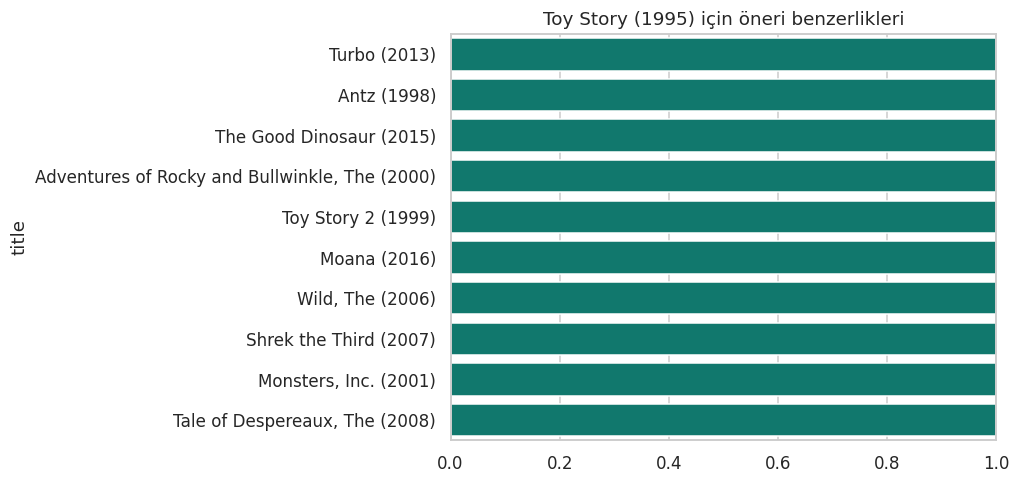

In [4]:
similarity_values = recommend(example_title, 10).similarity
sns.barplot(x=similarity_values.values, y=recommend(example_title, 10).title, color="#00897B")
plt.xlim(0, 1); plt.title(f"{example_title} için öneri benzerlikleri"); plt.show()
joblib.dump({"movies": movies, "vectorizer": vectorizer, "matrix": matrix,
             "model": model}, MODEL_DIR / "13_movielens_icerik.joblib")
json.dump({"movies": int(len(movies)), "genre_features": int(matrix.shape[1])},
          open(RESULT_DIR / "13_movielens_icerik.json", "w"), indent=2)

## Sonuç

Film listesi elle yazılmadı; 9.742 gerçek MovieLens kaydı kullanıldı. İçerik tabanlı yaklaşım yeni
kullanıcı için puan geçmişi olmadan çalışır, fakat yalnızca tür bilgisine dayandığı için oyuncu,
yönetmen ve özet gibi zengin içerik alanları eklenirse öneriler gelişir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **film türlerinden kosinüs benzerliği** biçimindedir.
Bu notebookta **tam MovieLens küçük kataloğu, tür EDA'sı, yeniden kullanılabilir yakın-komşu indeksi ve benzerlik grafiği** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).